# Explore the Dataset Structure

In [3]:
# Install PyTorch version compatible with P100 (CUDA 6.0)
!pip install torch==1.13.1+cu116 \
             torchvision==0.14.1+cu116 \
             --extra-index-url https://download.pytorch.org/whl/cu116 \
             --quiet

# Verify
import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"GPU name        : {torch.cuda.get_device_name(0)}")
print(f"CUDA capability : {torch.cuda.get_device_capability(0)}")

ERROR: Could not find a version that satisfies the requirement torch==1.13.1+cu116 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0)
ERROR: No matching distribution found for torch==1.13.1+cu116
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU name        : Tesla T4
CUDA capability : (7, 5)


In [4]:
import os

path = "/kaggle/input/competitions/g2net-gravitational-wave-detection"

# Just top level - don't go deep
for item in os.listdir(path):
    print(item)

sample_submission.csv
training_labels.csv
test
train


# Understanding The Labels

In [5]:
import pandas as pd
import numpy as np

BASE = "/kaggle/input/competitions/g2net-gravitational-wave-detection"

# ── Load labels ────────────────────────────────────
labels_df = pd.read_csv(f"{BASE}/training_labels.csv")

print("Shape:", labels_df.shape)
print("\nFirst 5 rows:")
print(labels_df.head())

print("\nClass distribution:")
print(labels_df['target'].value_counts())
print(f"\nPositive rate: {labels_df['target'].mean()*100:.1f}%")

# ── Load ONE raw signal ────────────────────────────
first_id = labels_df['id'][0]
print(f"\nFirst signal ID: {first_id}")

# Correct path function with updated base
def get_file_path(file_id, split="train"):
    return f"{BASE}/{split}/{file_id[0]}/{file_id[1]}/{file_id[2]}/{file_id}.npy"

signal_path = get_file_path(first_id)
print(f"Loading from: {signal_path}")

signal = np.load(signal_path)

print(f"\nRaw signal shape : {signal.shape}")
print(f"Data type        : {signal.dtype}")
print(f"Label for this   : {labels_df['target'][0]}")

Shape: (560000, 2)

First 5 rows:
           id  target
0  00000e74ad       1
1  00001f4945       0
2  0000661522       0
3  00007a006a       0
4  0000a38978       1

Class distribution:
target
0    280070
1    279930
Name: count, dtype: int64

Positive rate: 50.0%

First signal ID: 00000e74ad
Loading from: /kaggle/input/competitions/g2net-gravitational-wave-detection/train/0/0/0/00000e74ad.npy

Raw signal shape : (3, 4096)
Data type        : float64
Label for this   : 1


# Visualize Raw Signals

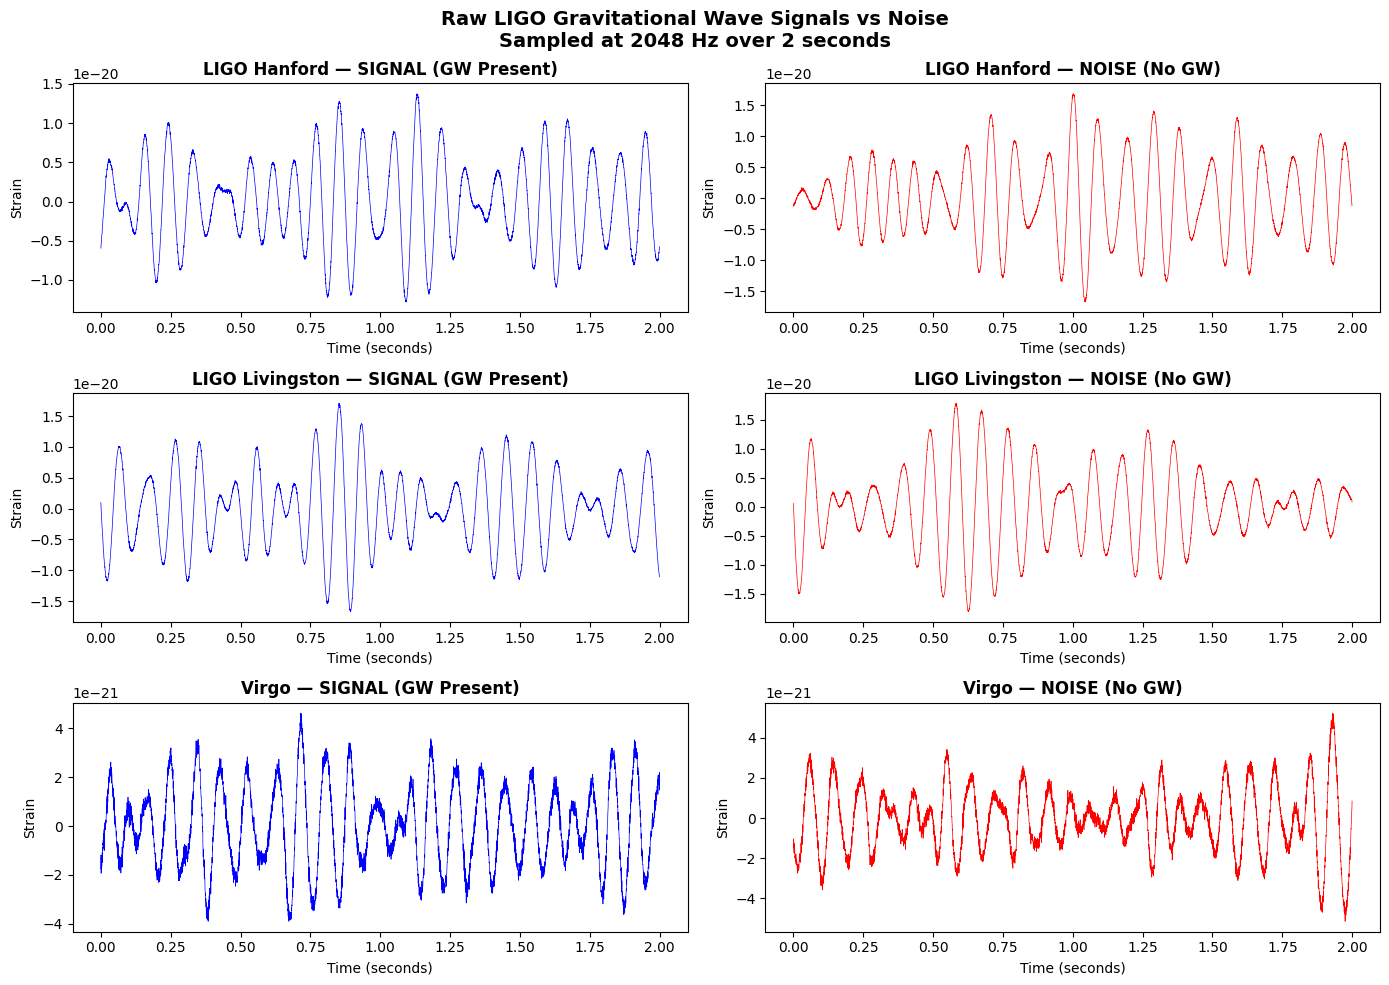

SIGNAL statistics:
  Mean   : -0.000000
  Std    : 0.000000
  Min    : -0.000000
  Max    : 0.000000

NOISE statistics:
  Mean   : -0.000000
  Std    : 0.000000
  Min    : -0.000000
  Max    : 0.000000


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ── Load one positive (signal) and one negative (noise) ──
def get_file_path(file_id, split="train"):
    return f"{BASE}/{split}/{file_id[0]}/{file_id[1]}/{file_id[2]}/{file_id}.npy"

# Get one signal (label=1) and one noise (label=0)
signal_id = labels_df[labels_df['target']==1]['id'].iloc[0]
noise_id  = labels_df[labels_df['target']==0]['id'].iloc[0]

signal_wave = np.load(get_file_path(signal_id))  # shape (3, 4096)
noise_wave  = np.load(get_file_path(noise_id))   # shape (3, 4096)

# ── Sampling rate ──────────────────────────────────
SAMPLE_RATE = 2048  # Hz — 2048 measurements per second
time_axis   = np.arange(4096) / SAMPLE_RATE  # convert to seconds

# ── Plot ───────────────────────────────────────────
detector_names = ['LIGO Hanford', 'LIGO Livingston', 'Virgo']

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i in range(3):
    # Signal column
    axes[i, 0].plot(time_axis, signal_wave[i], 
                    color='blue', linewidth=0.5)
    axes[i, 0].set_title(f'{detector_names[i]} — SIGNAL (GW Present)', 
                          fontweight='bold')
    axes[i, 0].set_xlabel('Time (seconds)')
    axes[i, 0].set_ylabel('Strain')

    # Noise column
    axes[i, 1].plot(time_axis, noise_wave[i], 
                    color='red', linewidth=0.5)
    axes[i, 1].set_title(f'{detector_names[i]} — NOISE (No GW)', 
                          fontweight='bold')
    axes[i, 1].set_xlabel('Time (seconds)')
    axes[i, 1].set_ylabel('Strain')

plt.suptitle('Raw LIGO Gravitational Wave Signals vs Noise\n'
             'Sampled at 2048 Hz over 2 seconds', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Basic signal statistics ────────────────────────
print("SIGNAL statistics:")
print(f"  Mean   : {signal_wave.mean():.6f}")
print(f"  Std    : {signal_wave.std():.6f}")
print(f"  Min    : {signal_wave.min():.6f}")
print(f"  Max    : {signal_wave.max():.6f}")

print("\nNOISE statistics:")
print(f"  Mean   : {noise_wave.mean():.6f}")
print(f"  Std    : {noise_wave.std():.6f}")
print(f"  Min    : {noise_wave.min():.6f}")
print(f"  Max    : {noise_wave.max():.6f}")

In [7]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from scipy import signal as scipy_signal
from sklearn.model_selection import train_test_split

BASE        = "/kaggle/input/competitions/g2net-gravitational-wave-detection"
SAMPLE_RATE = 2048
BATCH_SIZE  = 32

# ══════════════════════════════════════════════════
# STEP 4A — BANDPASS FILTER
# WHY: GW signals live in 20–500 Hz range
#      Everything outside is instrument noise
#      We surgically remove frequencies we don't need
# ══════════════════════════════════════════════════
def bandpass_filter(data, lowcut=20, highcut=500, fs=SAMPLE_RATE, order=4):
    # Nyquist frequency = half the sampling rate
    nyquist = fs / 2
    
    # Normalize cutoffs to Nyquist (scipy requires this)
    low  = lowcut  / nyquist
    high = highcut / nyquist
    
    # Butterworth filter — maximally flat in passband
    b, a = scipy_signal.butter(order, [low, high], btype='band')
    
    # Apply filter to each detector channel
    filtered = np.array([scipy_signal.filtfilt(b, a, data[i]) 
                         for i in range(data.shape[0])])
    return filtered

# ══════════════════════════════════════════════════
# STEP 4B — NORMALIZATION
# WHY: Raw strain values are 1e-20 scale
#      Neural networks work best with values near 0
#      We standardize each channel independently
# ══════════════════════════════════════════════════
def normalize(data):
    # For each detector channel independently
    normalized = np.zeros_like(data)
    for i in range(data.shape[0]):
        mean = data[i].mean()
        std  = data[i].std()
        # Avoid division by zero
        normalized[i] = (data[i] - mean) / (std + 1e-8)
    return normalized

# ══════════════════════════════════════════════════
# STEP 4C — FULL PREPROCESSING PIPELINE
# Combines filter + normalize into one function
# ══════════════════════════════════════════════════
def preprocess(data):
    data = bandpass_filter(data)  # remove out-of-band noise
    data = normalize(data)        # scale to unit variance
    return data.astype(np.float32)

# ══════════════════════════════════════════════════
# STEP 5A — CUSTOM PYTORCH DATASET
# WHY: Tells PyTorch how to load each sample
#      Applies preprocessing on-the-fly
# ══════════════════════════════════════════════════
class G2NetDataset(Dataset):
    def __init__(self, df, split="train"):
        self.df    = df.reset_index(drop=True)
        self.split = split

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        file_id = row['id']
        
        # Build file path
        path   = f"{BASE}/{self.split}/{file_id[0]}/{file_id[1]}/{file_id[2]}/{file_id}.npy"
        
        # Load + preprocess
        data   = np.load(path)          # shape: (3, 4096)
        data   = preprocess(data)       # filter + normalize
        
        # Convert to tensor
        tensor = torch.tensor(data, dtype=torch.float32)  # (3, 4096)
        
        # Label
        label  = torch.tensor(row['target'], dtype=torch.float32)
        
        return tensor, label

# ══════════════════════════════════════════════════
# STEP 5B — TRAIN/VALIDATION SPLIT
# WHY: We need held-out data to monitor overfitting
#      Using 80% train, 20% validation
#      stratify=target keeps 50/50 balance in both
# ══════════════════════════════════════════════════
labels_df = pd.read_csv(f"{BASE}/training_labels.csv")

# Use subset for faster training on Kaggle GPU
# Full 560k would take too long — 50k is enough to learn
SUBSET_SIZE = 50000
labels_df   = labels_df.sample(n=SUBSET_SIZE, random_state=42).reset_index(drop=True)

train_df, val_df = train_test_split(
    labels_df,
    test_size=0.2,
    random_state=42,
    stratify=labels_df['target']  # keep 50/50 in both splits
)

print(f"Train size      : {len(train_df)}")
print(f"Validation size : {len(val_df)}")
print(f"Train positive  : {train_df['target'].mean()*100:.1f}%")
print(f"Val positive    : {val_df['target'].mean()*100:.1f}%")

# ══════════════════════════════════════════════════
# STEP 5C — DATALOADERS
# ══════════════════════════════════════════════════
train_dataset = G2NetDataset(train_df, split="train")
val_dataset   = G2NetDataset(val_df,   split="train")

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                           shuffle=True,  num_workers=2)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, 
                           shuffle=False, num_workers=2)

# ── Sanity check one batch ─────────────────────────
signals, labels = next(iter(train_loader))
print(f"\nBatch signal shape : {signals.shape}")  # [32, 3, 4096]
print(f"Batch label shape  : {labels.shape}")    # [32]
print(f"Signal value range : {signals.min():.3f} to {signals.max():.3f}")
print(f"Labels in batch    : {labels.unique()}")

# ── Verify preprocessing worked ───────────────────
print(f"\nAfter normalization:")
print(f"  Mean  : {signals.mean():.6f}  (should be ~0)")
print(f"  Std   : {signals.std():.6f}   (should be ~1)")

Train size      : 40000
Validation size : 10000
Train positive  : 50.0%
Val positive    : 50.0%

Batch signal shape : torch.Size([32, 3, 4096])
Batch label shape  : torch.Size([32])
Signal value range : -0.000 to 0.000
Labels in batch    : tensor([0., 1.])

After normalization:
  Mean  : 0.000000  (should be ~0)
  Std   : 0.000000   (should be ~1)


In [8]:
def preprocess(data):
    # Keep as float64 during processing
    data = bandpass_filter(data)
    
    # Normalize in float64 (full precision)
    normalized = np.zeros_like(data, dtype=np.float64)
    for i in range(data.shape[0]):
        mean = data[i].mean()
        std  = data[i].std()
        normalized[i] = (data[i] - mean) / (std + 1e-38)  # 1e-38 for float64 scale
    
    # Convert to float32 AFTER normalization
    # Values are now ~N(0,1) — safe for float32
    return normalized.astype(np.float32)

# ── Quick verification ─────────────────────────────
test_signal = np.load(
    f"{BASE}/train/0/0/0/00000e74ad.npy"
)
print(f"Raw values     : {test_signal[0][:3]}")
print(f"Raw std        : {test_signal[0].std():.6e}")

processed = preprocess(test_signal)
print(f"\nProcessed values : {processed[0][:3]}")
print(f"Processed mean   : {processed.mean():.6f}  (should be ~0)")
print(f"Processed std    : {processed.std():.6f}   (should be ~1)")

Raw values     : [-5.94830548e-21 -5.84995448e-21 -5.42415169e-21]
Raw std        : 5.579398e-21

Processed values : [1.17994   0.9321849 0.7759837]
Processed mean   : -0.000000  (should be ~0)
Processed std    : 1.000000   (should be ~1)


In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from scipy import signal as scipy_signal
from scipy.signal import welch
import numpy as np
import pandas as pd
import time

DEVICE      = torch.device("cuda")   # T4 GPU ✅
BASE        = "/kaggle/input/competitions/g2net-gravitational-wave-detection"
SAMPLE_RATE = 2048
BATCH_SIZE  = 128    # larger batch — T4 has 16GB VRAM
CACHE_SIZE  = 50000  # back to 50k now that we have GPU
print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ══════════════════════════════════════════════════
# PREPROCESSING
# ══════════════════════════════════════════════════
def bandpass_filter(data, lowcut=20, highcut=500, fs=SAMPLE_RATE, order=4):
    nyquist   = fs / 2
    low, high = lowcut/nyquist, highcut/nyquist
    b, a      = scipy_signal.butter(order, [low, high], btype='band')
    return np.array([scipy_signal.filtfilt(b, a, data[i])
                     for i in range(data.shape[0])])

def whiten(data, fs=SAMPLE_RATE):
    whitened = np.zeros_like(data)
    for i in range(data.shape[0]):
        freqs, psd  = welch(data[i], fs=fs, nperseg=256)
        fft_freqs   = np.fft.rfftfreq(len(data[i]), d=1.0/fs)
        psd_interp  = np.interp(fft_freqs, freqs, psd)
        psd_interp  = np.clip(psd_interp, 1e-38, None)
        fft_data    = np.fft.rfft(data[i])
        whitened[i] = np.fft.irfft(fft_data / np.sqrt(psd_interp),
                                    n=len(data[i]))
    return whitened

def normalize(data):
    normalized = np.zeros_like(data, dtype=np.float64)
    for i in range(data.shape[0]):
        mean          = data[i].mean()
        std           = data[i].std()
        normalized[i] = (data[i] - mean) / (std + 1e-38)
    return normalized

def preprocess(data):
    data = bandpass_filter(data)
    data = whiten(data)
    data = normalize(data)
    return data.astype(np.float32)

def get_path(file_id, split="train"):
    return f"{BASE}/{split}/{file_id[0]}/{file_id[1]}/{file_id[2]}/{file_id}.npy"

# ══════════════════════════════════════════════════
# CACHE INTO RAM
# ══════════════════════════════════════════════════
print(f"\nCaching {CACHE_SIZE} signals into RAM...")
labels_df = pd.read_csv(f"{BASE}/training_labels.csv")
labels_df = labels_df.sample(n=CACHE_SIZE,
                              random_state=42).reset_index(drop=True)

X      = np.zeros((CACHE_SIZE, 3, 4096), dtype=np.float32)
y      = np.zeros(CACHE_SIZE,            dtype=np.float32)
start  = time.time()

for i, row in labels_df.iterrows():
    try:
        X[i] = preprocess(np.load(get_path(row['id'])))
        y[i] = row['target']
    except:
        continue
    if (i+1) % 5000 == 0:
        elapsed = time.time() - start
        eta     = (CACHE_SIZE - i - 1) / ((i+1)/elapsed)
        print(f"  {i+1}/{CACHE_SIZE} | "
              f"Elapsed: {elapsed:.0f}s | ETA: {eta:.0f}s")

print(f"Done! RAM used: ~{X.nbytes/1e6:.0f} MB | "
      f"Time: {time.time()-start:.0f}s")

# ══════════════════════════════════════════════════
# DATALOADERS
# ══════════════════════════════════════════════════
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

idx            = np.arange(CACHE_SIZE)
train_idx, val_idx = train_test_split(idx, test_size=0.2,
                                       random_state=42,
                                       stratify=y.astype(int))

train_loader = DataLoader(TensorDataset(X_tensor[train_idx],
                                         y_tensor[train_idx]),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_tensor[val_idx],
                                         y_tensor[val_idx]),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)}")

# ══════════════════════════════════════════════════
# MODEL
# ══════════════════════════════════════════════════
class CNNLSTM(nn.Module):
    def __init__(self):
        super(CNNLSTM, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(3,   32,  kernel_size=64, stride=4, padding=32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32,  64,  kernel_size=16, stride=2, padding=8),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64,  128, kernel_size=8,  stride=2, padding=4),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(
            input_size=128, hidden_size=128,
            num_layers=2,   batch_first=True,
            dropout=0.3,    bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x    = self.cnn(x)
        x    = x.permute(0, 2, 1)
        x, _ = self.lstm(x)
        x    = x[:, -1, :]
        return self.classifier(x).squeeze(1)

# ══════════════════════════════════════════════════
# TRAINING SETUP
# ══════════════════════════════════════════════════
model     = CNNLSTM().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(),
                              lr=1e-3, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', patience=2, factor=0.5)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")

# ══════════════════════════════════════════════════
# TRAINING LOOP
# ══════════════════════════════════════════════════
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for i, (signals, labels) in enumerate(loader):
        signals, labels = signals.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs    = model(signals)
        loss       = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        preds      = (torch.sigmoid(outputs) > 0.5).float()
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        total_loss += loss.item()
        if (i+1) % 50 == 0:
            print(f"  Batch {i+1}/{len(loader)} | "
                  f"Loss: {total_loss/(i+1):.4f} | "
                  f"Acc: {correct/total:.4f}", end='\r')
    return total_loss/len(loader), correct/total

def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for signals, labels in loader:
            signals, labels = signals.to(DEVICE), labels.to(DEVICE)
            outputs    = model(signals)
            loss       = criterion(outputs, labels)
            preds      = (torch.sigmoid(outputs) > 0.5).float()
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            total_loss += loss.item()
    return total_loss/len(loader), correct/total

# ══════════════════════════════════════════════════
# TRAIN 15 EPOCHS
# ══════════════════════════════════════════════════
EPOCHS        = 15
best_val_loss = float('inf')
history       = {'train_loss': [], 'val_loss': [],
                 'train_acc':  [], 'val_acc':  []}

print(f"\n{'Epoch':<8}{'Train Loss':<14}{'Train Acc':<14}"
      f"{'Val Loss':<14}{'Val Acc'}")
print("="*56)

for epoch in range(1, EPOCHS+1):
    print(f"Epoch {epoch}/{EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader,
                                             optimizer, criterion)
    val_loss,   val_acc   = validate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        flag = "✅"
    else:
        flag = ""

    print(f"{epoch:<8}{train_loss:<14.4f}{train_acc:<14.4f}"
          f"{val_loss:<14.4f}{val_acc:.4f} {flag}")

print(f"\nDone! Best Val Loss: {best_val_loss:.4f}")

Device : cuda
GPU    : Tesla T4

Caching 50000 signals into RAM...
  5000/50000 | Elapsed: 133s | ETA: 1201s
  10000/50000 | Elapsed: 259s | ETA: 1035s
  15000/50000 | Elapsed: 378s | ETA: 881s
  20000/50000 | Elapsed: 489s | ETA: 734s
  25000/50000 | Elapsed: 599s | ETA: 599s
  30000/50000 | Elapsed: 712s | ETA: 475s
  35000/50000 | Elapsed: 819s | ETA: 351s
  40000/50000 | Elapsed: 928s | ETA: 232s
  45000/50000 | Elapsed: 1040s | ETA: 116s
  50000/50000 | Elapsed: 1145s | ETA: 0s
Done! RAM used: ~2458 MB | Time: 1145s
Train: 40000 | Val: 10000
Parameters: 781,089

Epoch   Train Loss    Train Acc     Val Loss      Val Acc
Epoch 1/15
1       0.6932        0.5052        0.6931        0.5017 ✅
Epoch 2/15
2       0.6931        0.5024        0.6930        0.5154 ✅
Epoch 3/15
3       0.6930        0.5080        0.6932        0.5035 
Epoch 4/15
4       0.6930        0.5080        0.6933        0.5017 
Epoch 5/15
5       0.6930        0.5107        0.6930        0.5112 ✅
Epoch 6/15
6       0

Continuing training from epoch 15...

Epoch   Train Loss    Train Acc     Val Loss      Val Acc
Epoch 16/30
16      0.5209        0.7323        0.5229        0.7250 ✅
Epoch 17/30
17      0.5050        0.7445        0.5141        0.7346 ✅
Epoch 18/30
18      0.4931        0.7546        0.5122        0.7352 ✅
Epoch 19/30
19      0.4808        0.7631        0.5124        0.7364 
Epoch 20/30
20      0.4709        0.7705        0.5162        0.7329 
Epoch 21/30
21      0.4620        0.7775        0.5281        0.7333 
Epoch 22/30
22      0.4448        0.7894        0.5305        0.7331 
Epoch 23/30
23      0.4360        0.7964        0.5395        0.7309 
Epoch 24/30
24      0.4270        0.8015        0.5569        0.7287 
Epoch 25/30
25      0.4151        0.8114        0.5620        0.7266 
Epoch 26/30
26      0.4089        0.8159        0.5745        0.7226 
Epoch 27/30
27      0.4040        0.8197        0.5740        0.7243 
Epoch 28/30
28      0.3955        0.8244        0.5911       

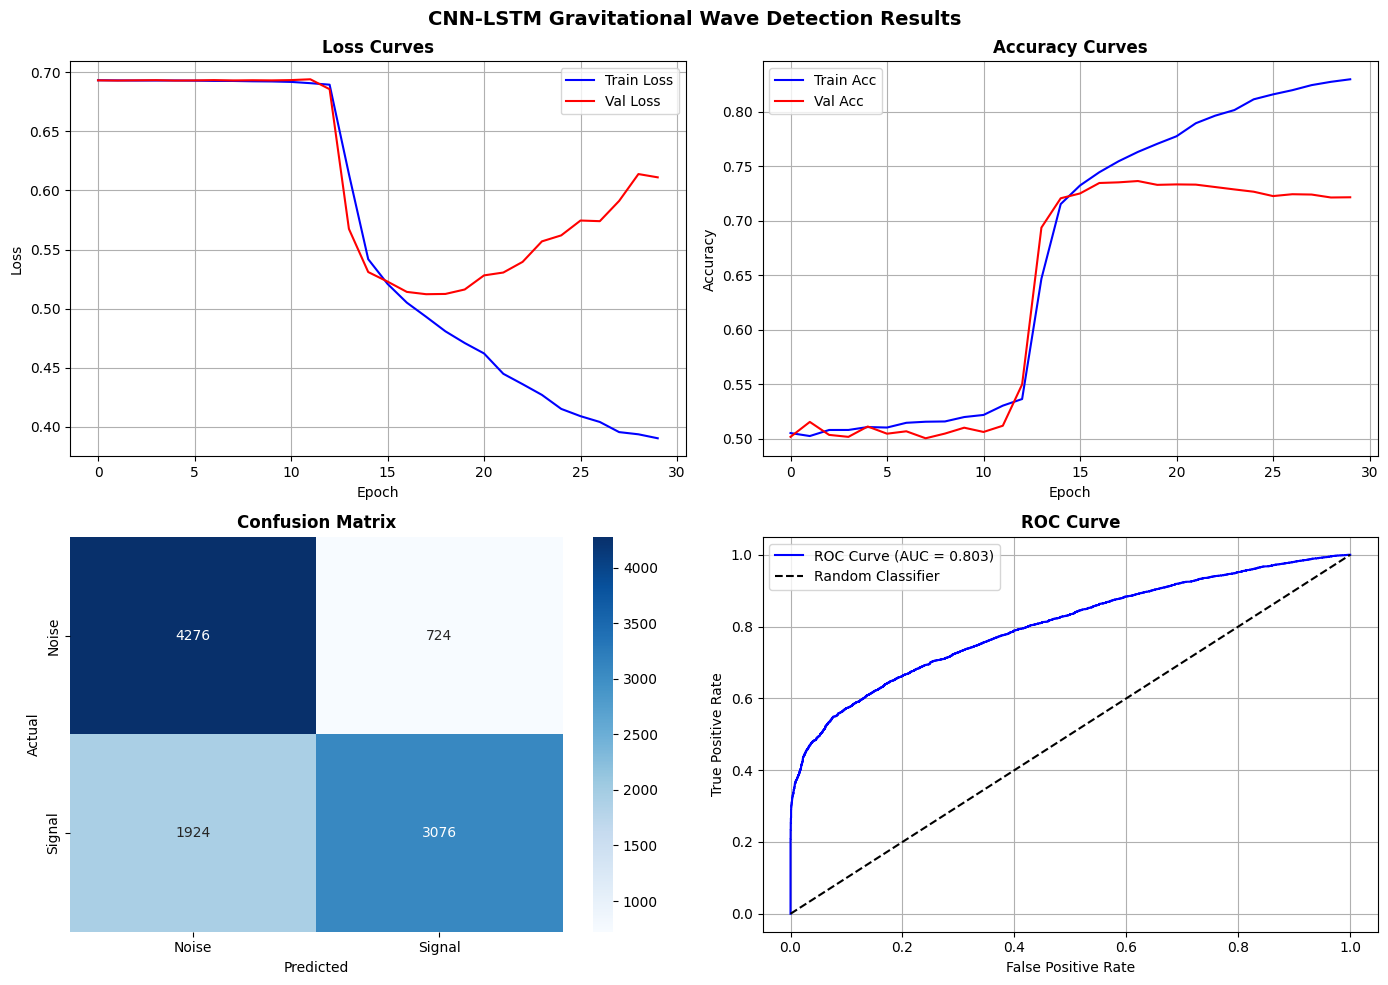


Results saved to results.png


In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, roc_auc_score)
import seaborn as sns

# ══════════════════════════════════════════════════
# CONTINUE TRAINING 15 MORE EPOCHS
# ══════════════════════════════════════════════════
print("Continuing training from epoch 15...")
print(f"\n{'Epoch':<8}{'Train Loss':<14}{'Train Acc':<14}"
      f"{'Val Loss':<14}{'Val Acc'}")
print("="*56)

for epoch in range(16, 31):
    print(f"Epoch {epoch}/30")
    train_loss, train_acc = train_one_epoch(model, train_loader,
                                             optimizer, criterion)
    val_loss,   val_acc   = validate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        flag = "✅"
    else:
        flag = ""

    print(f"{epoch:<8}{train_loss:<14.4f}{train_acc:<14.4f}"
          f"{val_loss:<14.4f}{val_acc:.4f} {flag}")

print(f"\nDone! Best Val Loss: {best_val_loss:.4f}")

# ══════════════════════════════════════════════════
# LOAD BEST MODEL FOR EVALUATION
# ══════════════════════════════════════════════════
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# ══════════════════════════════════════════════════
# COLLECT ALL PREDICTIONS
# ══════════════════════════════════════════════════
all_probs  = []
all_preds  = []
all_labels = []

with torch.no_grad():
    for signals, labels in val_loader:
        signals = signals.to(DEVICE)
        outputs = model(signals)
        probs   = torch.sigmoid(outputs).cpu().numpy()
        preds   = (probs > 0.5).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy().astype(int))

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ══════════════════════════════════════════════════
# METRICS
# ══════════════════════════════════════════════════
auc_score = roc_auc_score(all_labels, all_probs)
print("\n" + "="*50)
print("FINAL EVALUATION METRICS")
print("="*50)
print(classification_report(all_labels, all_preds,
                             target_names=['Noise (0)', 'Signal (1)']))
print(f"ROC-AUC Score: {auc_score:.4f}")

# ══════════════════════════════════════════════════
# PLOTS — 4 panels
# ══════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: Training curves ────────────────────────
axes[0,0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0,0].plot(history['val_loss'],   label='Val Loss',   color='red')
axes[0,0].set_title('Loss Curves',  fontweight='bold')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True)

# ── Plot 2: Accuracy curves ────────────────────────
axes[0,1].plot(history['train_acc'], label='Train Acc', color='blue')
axes[0,1].plot(history['val_acc'],   label='Val Acc',   color='red')
axes[0,1].set_title('Accuracy Curves', fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()
axes[0,1].grid(True)

# ── Plot 3: Confusion Matrix ───────────────────────
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1,0],
            xticklabels=['Noise','Signal'],
            yticklabels=['Noise','Signal'],
            cmap='Blues')
axes[1,0].set_title('Confusion Matrix', fontweight='bold')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')

# ── Plot 4: ROC Curve ──────────────────────────────
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1,1].plot(fpr, tpr, color='blue',
               label=f'ROC Curve (AUC = {auc_score:.3f})')
axes[1,1].plot([0,1], [0,1], 'k--', label='Random Classifier')
axes[1,1].set_title('ROC Curve',  fontweight='bold')
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].legend()
axes[1,1].grid(True)

plt.suptitle('CNN-LSTM Gravitational Wave Detection Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResults saved to results.png")